In [1]:
!pip install --user matplotlib
!pip install --user pandas
!pip install --user scipy
!pip install --user tqdm

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023

In [1]:
import matplotlib
%matplotlib inline

import _pickle as pickle
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scipy

from tqdm.notebook import tqdm

In [3]:
# data_dir = "/home/chanb/scratch/hint_rl_results/logs/chanb/openmath-dapo/"
# match_prefixes = [
#     "local_eval-hint_rl_0-epoch",
#     "local_eval-hint_rl_163-epoch",
# ]

runs = {
    "hint_rl": [
        "local_eval-hint_rl",
    ],
    "grpo": [
        "local_eval-grpo",
    ],
    "questa": [
        "local_eval-questa",
    ]
}
data_dir = "/home/chanb/scratch/hint_rl_results/logs/chanb/eval-math"
all_runs = dict()
for name, match_prefixes in runs.items():
    all_evals = []
    for match_prefix in match_prefixes:
        all_evals.extend(sorted([
            filename for filename in os.listdir(data_dir)
            if (
                os.path.isdir(os.path.join(data_dir, filename))
                and filename.startswith(match_prefix)
                and os.path.isdir(os.path.join(data_dir, filename, "rollout/0"))
                and len(os.listdir(os.path.join(data_dir, filename, "rollout/0"))) == 1853
            )
        ], key=lambda x: int(x.split("epoch")[1])))
    all_runs[name] = all_evals

In [4]:
all_runs

{'hint_rl': ['local_eval-hint_rl-epoch0epochstep13globalstep13',
  'local_eval-hint_rl-epoch1epochstep13globalstep27',
  'local_eval-hint_rl-epoch2epochstep13globalstep41',
  'local_eval-hint_rl-epoch3epochstep13globalstep55',
  'local_eval-hint_rl-epoch4epochstep13globalstep69',
  'local_eval-hint_rl-epoch5epochstep13globalstep83',
  'local_eval-hint_rl-epoch6epochstep13globalstep97',
  'local_eval-hint_rl-epoch7epochstep13globalstep111',
  'local_eval-hint_rl-epoch8epochstep13globalstep125',
  'local_eval-hint_rl-epoch9epochstep13globalstep139',
  'local_eval-hint_rl-epoch10epochstep13globalstep153',
  'local_eval-hint_rl-epoch11epochstep13globalstep167',
  'local_eval-hint_rl-epoch12epochstep13globalstep181',
  'local_eval-hint_rl-epoch13epochstep13globalstep195',
  'local_eval-hint_rl-epoch14epochstep13globalstep209',
  'local_eval-hint_rl-epoch15epochstep13globalstep223',
  'local_eval-hint_rl-epoch16epochstep13globalstep237',
  'local_eval-hint_rl-epoch17epochstep13globalstep251'

In [4]:
all_results = dict()

In [5]:
n_samples = 8
k_sampless = [1, 2, 4, 8]

In [6]:
def pass_k(n_success, n_samples, k_samples):
    pass_k = (
        1 - scipy.special.comb(
            n_samples - n_success,
            k_samples,
            exact=False,
        ) / scipy.special.comb(n_samples, k_samples, exact=False)
    )
    return pass_k

# def pass_k(n_success, n_samples, k_samples):
#     pass_k = n_success / n_samples
#     return pass_k

In [7]:
agg_filename = "agg_eval-hint_rl-success_rate.pkl"
if os.path.isfile(agg_filename):
    all_results = pickle.load(open(agg_filename, "rb"))
else:
    for eval_name in tqdm(all_evals):
        curr_dir = os.path.join(data_dir, eval_name)
        try:
            pretrained_steps = int(eval_name.split("hint_rl_")[1].split("-")[0])
        except:
            pretrained_steps = 0
        total_train_steps = pretrained_steps + int(eval_name.split("globalstep")[1])
        key = total_train_steps

        curr_pass_k_results = []
        for sample_filename in os.listdir(os.path.join(curr_dir, "rollout/0")):
            sample_file = os.path.join(curr_dir, "rollout/0", sample_filename)
            sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
            curr_pass_k_results.append([
                pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
                for k_samples in k_sampless
            ])

        curr_pass_k_results = np.mean(curr_pass_k_results, axis=0)

        all_results[key] = curr_pass_k_results
    pickle.dump(all_results, open(agg_filename, "wb"))

  0%|          | 0/49 [00:00<?, ?it/s]

In [8]:
baseline_dir = "/home/chanb/scratch/hint_rl_results/eval_results/per_model/local_eval-questa_no_hint"

baseline_pass_k_results = []
for sample_filename in os.listdir(os.path.join(baseline_dir, "rollout/0")):
    sample_file = os.path.join(baseline_dir, "rollout/0", sample_filename)
    sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
    baseline_pass_k_results.append([
        pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
        for k_samples in k_sampless
    ])

baseline_pass_k_results = np.mean(baseline_pass_k_results, axis=0)

In [9]:
baseline_pass_k_results

array([0.07332704, 0.12192583, 0.18859764, 0.26929304])

In [10]:
baseline_dir = "/home/chanb/scratch/hint_rl_results/eval_results/per_model/local_eval-questa_no_hint-paper_model"

baseline_pass_k_results_2 = []
for sample_filename in os.listdir(os.path.join(baseline_dir, "rollout/0")):
    sample_file = os.path.join(baseline_dir, "rollout/0", sample_filename)
    sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
    baseline_pass_k_results_2.append([
        pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
        for k_samples in k_sampless
    ])

baseline_pass_k_results_2 = np.mean(baseline_pass_k_results_2, axis=0)

In [11]:
baseline_pass_k_results_2

array([0.33007285, 0.41319096, 0.49127284, 0.56395035])

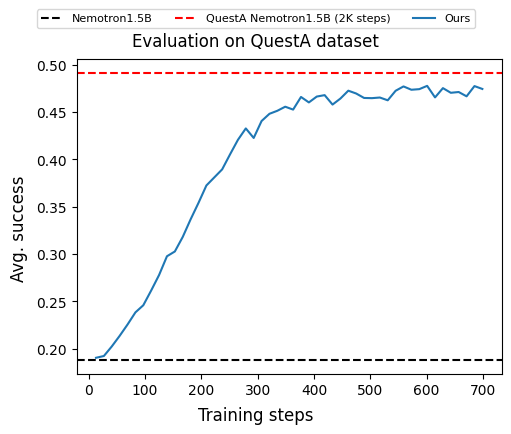

In [12]:
n_rows = 1
n_cols = 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 4.0 * n_rows), layout="constrained")

log_k = 2

x_range = sorted(all_results.keys())
y_vals = [
    all_results[key][log_k] for key in x_range
]

ax = axes
ax.axhline(
    baseline_pass_k_results[log_k],
    c="black",
    linestyle="--",
    label="Nemotron1.5B",
)
ax.axhline(
    baseline_pass_k_results_2[log_k],
    c="red",
    linestyle="--",
    label="QuestA Nemotron1.5B (2K steps)",
)
ax.plot(
    x_range,
    y_vals,
    label="Ours",
)
# ax.set_xticks(x_range)
# ax.set_ylim(-0.1, 1.1)

fig.suptitle("Evaluation on QuestA dataset")
# fig.supylabel("Pass@4")
fig.supylabel("Avg. success")
fig.supxlabel("Training steps")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

plt.show()

In [13]:
all_results

{13: array([0.07285483, 0.12192583, 0.19053273, 0.27361036]),
 27: array([0.07278737, 0.1225426 , 0.19241385, 0.27846735]),
 41: array([0.07798165, 0.12990517, 0.20249017, 0.29303832]),
 55: array([0.08256881, 0.13778814, 0.21369208, 0.30437129]),
 69: array([0.08540205, 0.14395575, 0.22565724, 0.32649757]),
 83: array([0.091136  , 0.15305296, 0.23848585, 0.34268753]),
 97: array([0.09430653, 0.15833398, 0.24601804, 0.35024285]),
 111: array([0.10078251, 0.16918511, 0.26159895, 0.36913114]),
 125: array([0.10752833, 0.18036389, 0.27793539, 0.39233675]),
 139: array([0.11569077, 0.19402899, 0.29774111, 0.41176471]),
 153: array([0.11913114, 0.19830776, 0.30279084, 0.41878036]),
 167: array([0.12850783, 0.21151029, 0.31812505, 0.43389099]),
 181: array([0.13977334, 0.22717986, 0.33672809, 0.45223961]),
 195: array([0.15184835, 0.24346619, 0.35412844, 0.47166757]),
 209: array([0.16162979, 0.2578637 , 0.37248477, 0.49271452]),
 237: array([0.17829196, 0.27673271, 0.38949194, 0.5008095 ]),